In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# !pip -q uninstall -y wfdb pandas
# !pip -q install pandas==2.1.4 wfdb==4.1.2


In [3]:
import os
import wfdb
import numpy as np

# ✅ Your dataset path (confirmed from your folder tree)
DATASET_ROOT = "/kaggle/input/mith-normal-sinus-dataset/mit-bih-normal-sinus-rhythm-database-1.0.0"

# Read RECORDS file
with open(os.path.join(DATASET_ROOT, "RECORDS")) as f:
    records = [line.strip() for line in f if line.strip()]

print("Total records:", len(records))
print("Records:", records)

# ---- Pick ONE record ----
rec = records[0]
print("\nShowing RR intervals for record:", rec)

# Load sampling frequency
fs = wfdb.rdheader(os.path.join(DATASET_ROOT, rec)).fs

# Load beat annotations
ann = wfdb.rdann(os.path.join(DATASET_ROOT, rec), "atr")
r_samples = np.array(ann.sample)

# Compute RR intervals (seconds)
rr = np.diff(r_samples) / fs

# Optional physiological filter
rr = rr[(rr > 0.2) & (rr < 3.0)]

print("\nFirst 40 RR intervals (seconds):")
print(np.round(rr[:40], 4))

print("\nTotal RR intervals:", len(rr))


Total records: 18
Records: ['16265', '16272', '16273', '16420', '16483', '16539', '16773', '16786', '16795', '17052', '17453', '18177', '18184', '19088', '19090', '19093', '19140', '19830']

Showing RR intervals for record: 16265

First 40 RR intervals (seconds):
[0.3984 0.6016 0.6094 0.6016 0.625  0.6094 0.625  0.5938 0.6016 0.6172
 0.6172 0.6484 0.625  0.6172 0.625  0.6484 0.6484 0.6406 0.625  0.6328
 0.625  0.6172 0.6172 0.625  0.6172 0.6016 0.6172 0.625  0.6328 0.6172
 0.6328 0.6562 0.6562 0.6641 0.6484 0.6406 0.6641 0.6875 0.6562 0.6406]

Total RR intervals: 100650


In [4]:
# !pip -q install -U "pandas==2.2.3" "wfdb==4.3.0"

In [5]:
# # ============================================================
# # KAGGLE FULL NOTEBOOK (ALL-IN-ONE) ✅  (MODIFIED FOR MIT NSRDB - 18 RECORDS)
# # RR Interval Imputation on MIT-BIH Normal Sinus Rhythm Database (nsrdb)
# #
# # ✅ Loads RR intervals from WFDB annotation files (*.atr as ann)
# # ✅ RR is in SECONDS (s)
# # ✅ Builds TRUE 5-minute segments (300 seconds each)
# # ✅ Converts variable-length 5-min segments -> fixed length (TARGET_LEN beats)
# # ✅ Trains LSTM Generator (residual) + WGAN-GP Critic (CNN)
# # ✅ Missing-only MAE + physiology dRR loss + optional smoothness
# # ✅ Warmup epochs (reconstruction first) to reduce MAE
# # ✅ Missing pattern: 50% contiguous block, 50% scattered
# # ✅ Debug prints: missing indices, true, pred, abs error
# # ✅ Plot: true / baseline fill / imputed, mark missing points
# # ============================================================

# import os, random
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import wfdb

# # -------------------------
# # CONFIG  (SECONDS)
# # -------------------------
# DATASET_ROOT = "/kaggle/input/mith-normal-sinus-dataset/mit-bih-normal-sinus-rhythm-database-1.0.0"

# SEG_S        = 300.0            # 5 minutes
# TARGET_LEN   = 400              # fixed beats per segment
# MIN_LEN_KEEP = 250              # discard too-short segments (<250 beats)

# K_MISSING    = 5
# FILL_MODE    = "ffill"          # "mean" or "ffill"

# BATCH_SIZE   = 32
# EPOCHS       = 30
# WARMUP_EPOCHS= 5
# N_CRITIC     = 1

# LR_G         = 1e-4
# LR_D         = 1e-4

# LAMBDA_MISS  = 500.0
# LAMBDA_DRR   = 2.0
# LAMBDA_SMOOTH= 0.0

# GP_LAMBDA    = 10.0
# SEED         = 42

# # -------------------------
# # Reproducibility
# # -------------------------
# def seed_all(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)

# seed_all(SEED)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Device:", device)

# # ============================================================
# # 1) LOAD RR FROM WFDB ANNOTATIONS (*.atr for MIT NSRDB)
# #    RR computed in SECONDS: diff(samples)/fs
# # ============================================================
# def list_records(dataset_root: str):
#     rec_path = os.path.join(dataset_root, "RECORDS")
#     if os.path.isfile(rec_path):
#         with open(rec_path, "r") as f:
#             recs = [ln.strip() for ln in f if ln.strip()]
#         return recs
#     recs = sorted([fn.replace(".hea", "") for fn in os.listdir(dataset_root) if fn.endswith(".hea")])
#     return recs

# def load_rr_records_from_wfdb(dataset_root: str, ann_ext="atr", verbose=True):
#     rr_dict, fs_dict = {}, {}
#     recs = list_records(dataset_root)
#     if verbose:
#         print(f"Found {len(recs)} records.")

#     for rec in recs:
#         try:
#             rec_path = os.path.join(dataset_root, rec)
#             header = wfdb.rdheader(rec_path)
#             fs = float(header.fs) if header.fs is not None else None
#             if fs is None:
#                 raise RuntimeError("Header fs is None")

#             # ✅ MIT NSRDB beat annotations are .atr
#             ann = wfdb.rdann(rec_path, ann_ext)
#             samples = np.asarray(ann.sample, dtype=np.int64)
#             if samples.size < 2:
#                 raise RuntimeError("Not enough annotations")

#             # ✅ RR in seconds
#             rr_s = (np.diff(samples) / fs).astype(np.float32)

#             # cleaning
#             rr_s = rr_s[np.isfinite(rr_s)]
#             rr_s = rr_s[(rr_s > 0.2) & (rr_s < 3.0)]

#             if rr_s.size < 1000:
#                 raise RuntimeError(f"Too few RR after cleaning: {rr_s.size}")

#             rr_dict[rec] = rr_s
#             fs_dict[rec] = fs
#         except Exception as e:
#             if verbose:
#                 print(f"Skip {rec}: {e}")

#     if verbose:
#         print(f"\nLoaded {len(rr_dict)} RR records (from annotations).")
#         if len(rr_dict) > 0:
#             lens = [len(v) for v in rr_dict.values()]
#             print(f"RR length (#intervals): min={np.min(lens)} mean={np.mean(lens):.1f} max={np.max(lens)}")

#             all_rr = np.concatenate(list(rr_dict.values())).astype(np.float64)
#             p1, p50, p99 = np.percentile(all_rr, [1, 50, 99])
#             print("\nRR scale check (seconds):")
#             print(f"  1% / 50% / 99%: {p1:.4f} / {p50:.4f} / {p99:.4f}")
#             hr = 60.0 / all_rr
#             print("HR sanity (BPM): min={:.1f} mean={:.1f} max={:.1f}".format(
#                 np.min(hr), np.mean(hr), np.max(hr)
#             ))

#     return rr_dict, fs_dict

# rr_dict, fs_dict = load_rr_records_from_wfdb(DATASET_ROOT, ann_ext="atr", verbose=True)
# assert len(rr_dict) > 0, "❌ rr_dict empty. Check DATASET_ROOT or ann_ext."

# # ============================================================
# # 2) BUILD TRUE 5-MINUTE SEGMENTS (time-based, seconds)
# #    ✅ Keep remainder time (better than resetting to 0)
# # ============================================================
# def split_into_time_segments(rr_s: np.ndarray, seg_s=300.0):
#     segments = []
#     acc = 0.0
#     cur = []
#     for v in rr_s:
#         v = float(v)
#         cur.append(v)
#         acc += v
#         if acc >= seg_s:
#             segments.append(np.asarray(cur, dtype=np.float32))
#             acc -= seg_s      # ✅ keep remainder time
#             cur = []
#     return segments

# def make_fixed_length(seg: np.ndarray, target_len=400, min_keep=250):
#     L = len(seg)
#     if L < min_keep:
#         return None, None
#     if L >= target_len:
#         start = np.random.randint(0, L - target_len + 1)
#         x = seg[start:start+target_len].copy()
#         valid = np.ones((target_len,), dtype=np.float32)
#         return x, valid
#     else:
#         x = np.empty((target_len,), dtype=np.float32)
#         valid = np.zeros((target_len,), dtype=np.float32)
#         x[:L] = seg
#         valid[:L] = 1.0
#         x[L:] = seg[-1]
#         return x, valid

# segments_by_patient = {}
# fixed_samples = []

# for pid, rr in rr_dict.items():
#     segs = split_into_time_segments(rr, seg_s=SEG_S)
#     segments_by_patient[pid] = segs
#     for seg in segs:
#         x, valid = make_fixed_length(seg, target_len=TARGET_LEN, min_keep=MIN_LEN_KEEP)
#         if x is not None:
#             fixed_samples.append((pid, x, valid))

# print(f"\nBuilt {len(fixed_samples)} fixed-length samples from 5-min segments.")
# print("Example per-patient segment counts (original variable-length):")
# for pid in sorted(list(segments_by_patient.keys()))[:5]:
#     print(f"  {pid} => {len(segments_by_patient[pid])} segments (5 min each)")
# print("  ...")

# # ============================================================
# # 3) TRAIN/TEST SPLIT (PATIENT-WISE ✅)
# # ============================================================
# all_pids = sorted(list(rr_dict.keys()))
# random.shuffle(all_pids)

# n_train = int(0.8 * len(all_pids))
# train_pids = set(all_pids[:n_train])
# test_pids  = set(all_pids[n_train:])

# train_samples = [(pid,x,v) for (pid,x,v) in fixed_samples if pid in train_pids]
# test_samples  = [(pid,x,v) for (pid,x,v) in fixed_samples if pid in test_pids]

# print(f"\nPatient-wise split:")
# print(f"  Train patients: {len(train_pids)} | Train samples: {len(train_samples)}")
# print(f"  Test  patients: {len(test_pids)}  | Test samples : {len(test_samples)}")

# # ============================================================
# # 4) DATASET + MASKING (avoid padded positions)
# # ============================================================
# class RR5MinDataset(Dataset):
#     def __init__(self, samples):
#         self.samples = samples
#     def __len__(self):
#         return len(self.samples)
#     def __getitem__(self, idx):
#         pid, x, valid = self.samples[idx]
#         return pid, torch.tensor(x, dtype=torch.float32), torch.tensor(valid, dtype=torch.float32)

# def make_mask_and_corrupt(x, valid_mask, K=5, fill_mode="ffill"):
#     B, T = x.shape
#     m = torch.ones((B, T), device=x.device)
#     idx_missing_list = []

#     for b in range(B):
#         valid_idx = torch.where(valid_mask[b] > 0.5)[0]
#         if valid_idx.numel() <= K:
#             idx = valid_idx
#         else:
#             if torch.rand(1, device=x.device).item() < 0.5:
#                 # contiguous block
#                 min_i = int(valid_idx.min().item())
#                 max_i = int(valid_idx.max().item())
#                 start = torch.randint(min_i, max_i - K + 2, (1,), device=x.device).item()
#                 idx = torch.arange(start, start + K, device=x.device)
#             else:
#                 # scattered
#                 perm = valid_idx[torch.randperm(valid_idx.numel(), device=x.device)]
#                 idx = perm[:K]

#         m[b, idx] = 0.0
#         idx_missing_list.append(idx)

#     if fill_mode == "mean":
#         obs_sum = (x * m).sum(dim=1, keepdim=True)
#         obs_cnt = m.sum(dim=1, keepdim=True).clamp(min=1.0)
#         fill = obs_sum / obs_cnt
#         x_obs = x * m + fill * (1.0 - m)

#     elif fill_mode == "ffill":
#         x_obs = x.clone()
#         for b in range(B):
#             missing = (m[b] == 0)
#             valid_idx = torch.where(valid_mask[b] > 0.5)[0]
#             if valid_idx.numel() == 0:
#                 continue
#             first = int(valid_idx[0].item())
#             prev = x_obs[b, first].item()
#             for t in range(T):
#                 if valid_mask[b, t] < 0.5:
#                     continue
#                 if missing[t]:
#                     x_obs[b, t] = prev
#                 else:
#                     prev = x_obs[b, t].item()
#     else:
#         raise ValueError("fill_mode must be 'mean' or 'ffill'")

#     return x_obs, m, idx_missing_list

# def drr(x):
#     dx = x[:, 1:] - x[:, :-1]
#     dx = torch.cat([torch.zeros((x.size(0), 1), device=x.device), dx], dim=1)
#     return dx

# # ============================================================
# # 5) MODELS
# # ============================================================
# class LSTMGeneratorResidual(nn.Module):
#     def __init__(self, hidden=96, num_layers=2, dropout=0.1):
#         super().__init__()
#         self.lstm = nn.LSTM(
#             input_size=4, hidden_size=hidden, num_layers=num_layers,
#             dropout=dropout if num_layers > 1 else 0.0,
#             batch_first=True, bidirectional=True
#         )
#         self.head = nn.Sequential(
#             nn.Linear(hidden * 2, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, 1)
#         )

#     def forward(self, x_base, m, noise):
#         dx = drr(x_base)
#         inp = torch.stack([x_base, m, dx, noise], dim=-1)
#         h, _ = self.lstm(inp)
#         delta = self.head(h).squeeze(-1)
#         return delta

# class CNNWganCritic(nn.Module):
#     def __init__(self, channels=64, kernel=5):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Conv1d(1, channels, kernel, padding=kernel//2),
#             nn.LeakyReLU(0.2),
#             nn.Conv1d(channels, channels, kernel, padding=kernel//2),
#             nn.LeakyReLU(0.2),
#             nn.Conv1d(channels, channels, kernel, padding=kernel//2),
#             nn.LeakyReLU(0.2),
#         )
#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.fc = nn.Linear(channels, 1)

#     def forward(self, x):
#         x = x.unsqueeze(1)
#         h = self.net(x)
#         h = self.pool(h).squeeze(-1)
#         return self.fc(h).squeeze(-1)

# def gradient_penalty(critic, real, fake, gp_lambda=10.0):
#     B = real.size(0)
#     eps = torch.rand(B, 1, device=real.device).expand_as(real)
#     x_hat = eps * real + (1 - eps) * fake
#     x_hat.requires_grad_(True)

#     scores = critic(x_hat)
#     grads = torch.autograd.grad(
#         outputs=scores, inputs=x_hat,
#         grad_outputs=torch.ones_like(scores),
#         create_graph=True, retain_graph=True, only_inputs=True
#     )[0]

#     grads = grads.view(B, -1)
#     gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean() * gp_lambda
#     return gp

# # ============================================================
# # 7) TRAIN
# # ============================================================
# def train_wgan(train_samples):
#     ds = RR5MinDataset(train_samples)
#     dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
#     print("Train samples:", len(ds))

#     G = LSTMGeneratorResidual(hidden=96, num_layers=2, dropout=0.1).to(device)
#     D = CNNWganCritic(channels=64, kernel=5).to(device)

#     opt_g = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.9))
#     opt_d = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.9))

#     all_vals = np.concatenate([x for (_, x, _) in train_samples]).astype(np.float64)
#     lo, hi = np.percentile(all_vals, [0.5, 99.5]).astype(np.float32)
#     lo, hi = float(lo), float(hi)
#     print(f"RR clamp range (0.5%..99.5%): [{lo:.4f}, {hi:.4f}] s")

#     for ep in range(1, EPOCHS + 1):
#         G.train(); D.train()
#         d_sum = g_sum = miss_sum = drr_sum = 0.0

#         for _, x_s, valid in dl:
#             x_s = x_s.to(device)
#             valid = valid.to(device)

#             mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
#             var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
#             std = torch.sqrt(var).clamp(min=1e-6)
#             x = (x_s - mu) / std

#             # ---- Critic ----
#             for _ in range(N_CRITIC):
#                 with torch.no_grad():
#                     x_base, m, _ = make_mask_and_corrupt(x, valid, K=K_MISSING, fill_mode=FILL_MODE)
#                     noise = torch.rand_like(x) * (1.0 - m)
#                     delta = G(x_base, m, noise)
#                     x_hat = m * x + (1.0 - m) * (x_base + delta)
#                     x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

#                 real_score = D(x)
#                 fake_score = D(x_hat)
#                 gp = gradient_penalty(D, x, x_hat, gp_lambda=GP_LAMBDA)
#                 d_loss = (fake_score.mean() - real_score.mean()) + gp

#                 opt_d.zero_grad(set_to_none=True)
#                 d_loss.backward()
#                 opt_d.step()

#             # ---- Generator ----
#             x_base, m, _ = make_mask_and_corrupt(x, valid, K=K_MISSING, fill_mode=FILL_MODE)
#             noise = torch.rand_like(x) * (1.0 - m)
#             delta = G(x_base, m, noise)
#             x_hat = m * x + (1.0 - m) * (x_base + delta)
#             x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

#             adv = -D(x_hat).mean()
#             if ep <= WARMUP_EPOCHS:
#                 adv = 0.0 * adv

#             miss_mask = (1.0 - m) * valid
#             denom = miss_mask.sum().clamp(min=1.0)
#             miss_mae = (torch.abs(x_hat - x) * miss_mask).sum() / denom

#             drr_hat = x_hat[:, 1:] - x_hat[:, :-1]
#             drr_true = x[:, 1:] - x[:, :-1]
#             valid_pair = valid[:, 1:] * valid[:, :-1]
#             m_pair = m[:, 1:] * m[:, :-1]
#             miss_drr_mask = (1.0 - m_pair) * valid_pair
#             denom_drr = miss_drr_mask.sum().clamp(min=1.0)
#             drr_loss = (torch.abs(drr_hat - drr_true) * miss_drr_mask).sum() / denom_drr

#             smooth = torch.mean(torch.abs(drr_hat) * valid_pair) if LAMBDA_SMOOTH > 0 else torch.tensor(0.0, device=device)

#             g_loss = adv + LAMBDA_MISS * miss_mae + LAMBDA_DRR * drr_loss + LAMBDA_SMOOTH * smooth

#             opt_g.zero_grad(set_to_none=True)
#             g_loss.backward()
#             opt_g.step()

#             d_sum += float(d_loss.item())
#             g_sum += float(g_loss.item())
#             miss_sum += float(miss_mae.item())
#             drr_sum += float(drr_loss.item())

#         print(
#             f"Epoch {ep:03d} | D={d_sum/len(dl):.4f} | G={g_sum/len(dl):.4f} | "
#             f"MissMAE(z)={miss_sum/len(dl):.4f} | dRRloss(z)={drr_sum/len(dl):.4f}"
#         )

#     return G, D, lo, hi

# # ============================================================
# # 8) INFERENCE + DEBUG
# # ============================================================
# @torch.no_grad()
# def impute_one_sample(G, x_s_np, valid_np, lo, hi, K=5, verbose=True):
#     G.eval()
#     x_s = torch.tensor(x_s_np, dtype=torch.float32, device=device).unsqueeze(0)
#     valid = torch.tensor(valid_np, dtype=torch.float32, device=device).unsqueeze(0)

#     mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
#     var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
#     std = torch.sqrt(var).clamp(min=1e-6)
#     x = (x_s - mu) / std

#     x_base, m, idx_list = make_mask_and_corrupt(x, valid, K=K, fill_mode=FILL_MODE)
#     idx_missing = idx_list[0].detach().cpu().numpy()

#     noise = torch.rand_like(x) * (1.0 - m)
#     delta = G(x_base, m, noise)
#     x_hat = m * x + (1.0 - m) * (x_base + delta)
#     x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

#     x_hat_s  = x_hat * std + mu
#     x_base_s = x_base * std + mu

#     x_true    = x_s.squeeze(0).cpu().numpy()
#     x_imputed = x_hat_s.squeeze(0).cpu().numpy()
#     x_base_out= x_base_s.squeeze(0).cpu().numpy()
#     valid_out = valid.squeeze(0).cpu().numpy()

#     idx_missing = np.array([i for i in idx_missing if valid_out[i] > 0.5], dtype=int)
#     true_missing = x_true[idx_missing]
#     pred_missing = x_imputed[idx_missing]
#     abs_err = np.abs(pred_missing - true_missing)

#     mae = float(np.mean(abs_err)) if abs_err.size > 0 else 0.0
#     rmse = float(np.sqrt(np.mean((pred_missing - true_missing) ** 2))) if abs_err.size > 0 else 0.0

#     if verbose:
#         order = np.argsort(idx_missing)
#         idx_s  = idx_missing[order]
#         true_s = true_missing[order]
#         pred_s = pred_missing[order]
#         err_s  = abs_err[order]

#         print("\n================ Missing-value Debug ================")
#         print(f"K={K} missing points (valid only)")
#         print("Deleted indices        :", idx_s.tolist())
#         print("Deleted TRUE values (s):", np.round(true_s, 6).tolist())
#         print("Predicted values    (s):", np.round(pred_s, 6).tolist())
#         print("Abs error          (s) :", np.round(err_s, 6).tolist())
#         print(f"Missing-only MAE={mae:.6f} s | RMSE={rmse:.6f} s")
#         print("=====================================================\n")

#     return x_true, x_base_out, x_imputed, valid_out, idx_missing, mae, rmse

# def plot_imputation(x_true, x_base, x_imputed, idx_missing, valid_mask, title="RR Imputation (5-min segment)"):
#     T = len(x_true)
#     plt.figure(figsize=(14,4))
#     valid_idx = np.where(valid_mask > 0.5)[0]
#     t0, t1 = (int(valid_idx[0]), int(valid_idx[-1])) if valid_idx.size > 0 else (0, T-1)

#     t = np.arange(T)
#     plt.plot(t, x_true, label="True RR (s)")
#     plt.plot(t, x_base, label="Masked/Filled RR (s)")
#     plt.plot(t, x_imputed, label="Imputed RR (s)")
#     if len(idx_missing) > 0:
#         plt.scatter(idx_missing, x_true[idx_missing], marker="x", s=80, label="Deleted (true)")
#         plt.scatter(idx_missing, x_imputed[idx_missing], marker="o", s=70, label="Predicted")

#     plt.axvspan(t1+0.5, T-0.5, alpha=0.08)
#     plt.title(title)
#     plt.legend()
#     plt.grid(True, alpha=0.25)
#     plt.xlim(t0, T-1)
#     plt.show()

# # ============================================================
# # 9) RUN TRAIN + TEST
# # ============================================================
# G, D, lo, hi = train_wgan(train_samples)

# pid, x_s_np, valid_np = test_samples[0]
# print("Test patient:", pid)

# x_true, x_base, x_imputed, valid_out, idx_missing, mae, rmse = impute_one_sample(
#     G, x_s_np, valid_np, lo=lo, hi=hi, K=K_MISSING, verbose=True
# )

# plot_imputation(
#     x_true, x_base, x_imputed, idx_missing, valid_out,
#     title=f"{pid} | MIT NSRDB | 5-min segment fixed to {TARGET_LEN} beats | MAE={mae:.6f} s RMSE={rmse:.6f} s"
# )

# MODEL_PATH = "/kaggle/working/rr_imputer_mit_nsrdb_5min_wgangp_lstm_residual_seconds.pt"
# torch.save({
#     "G_state": G.state_dict(),
#     "D_state": D.state_dict(),
#     "lo": lo,
#     "hi": hi,
#     "seg_s": SEG_S,
#     "target_len": TARGET_LEN,
#     "min_len_keep": MIN_LEN_KEEP,
#     "k_missing": K_MISSING,
#     "fill_mode": FILL_MODE,
#     "missing_pattern": "50% contiguous block, 50% scattered",
#     "normalize": "per-segment z-score",
#     "units": "seconds",
#     "dataset": "MIT-BIH Normal Sinus Rhythm Database (nsrdb)"
# }, MODEL_PATH)
# print("Saved:", MODEL_PATH)


**3 mintues on mith random**

Device: cuda
Found 18 records.

Loaded 18 RR records (from annotations).

RR scale check (seconds):
  1% / 50% / 99%: 0.3281 / 0.7656 / 1.2031
HR sanity (BPM): min=23.3 mean=83.3 max=295.4

Built 21081 fixed-length samples from 1-min segments.

Patient-wise split:
  Train patients: 14 | Train samples: 16605
  Test  patients: 4  | Test samples : 4476
Train samples: 16605 | Using batch size: 32 | Batches: 519
RR clamp range (0.5%..99.5%): [0.3125, 1.1953] s
Epoch 001 | D=1.1952 | G=325.2478 | MissMAE(z)=0.6481 | dRRloss(z)=0.6108
Epoch 002 | D=-0.1157 | G=300.3283 | MissMAE(z)=0.5984 | dRRloss(z)=0.5740
Epoch 003 | D=-0.1954 | G=289.8364 | MissMAE(z)=0.5775 | dRRloss(z)=0.5514
Epoch 004 | D=-0.2238 | G=280.0981 | MissMAE(z)=0.5580 | dRRloss(z)=0.5381
Epoch 005 | D=-0.2168 | G=268.4484 | MissMAE(z)=0.5349 | dRRloss(z)=0.5096
Epoch 006 | D=-0.2165 | G=261.4072 | MissMAE(z)=0.5216 | dRRloss(z)=0.4961
Epoch 007 | D=-0.2110 | G=257.9120 | MissMAE(z)=0.5184 | dRRloss(z)=0.4922
Epoch 008 | D=-0

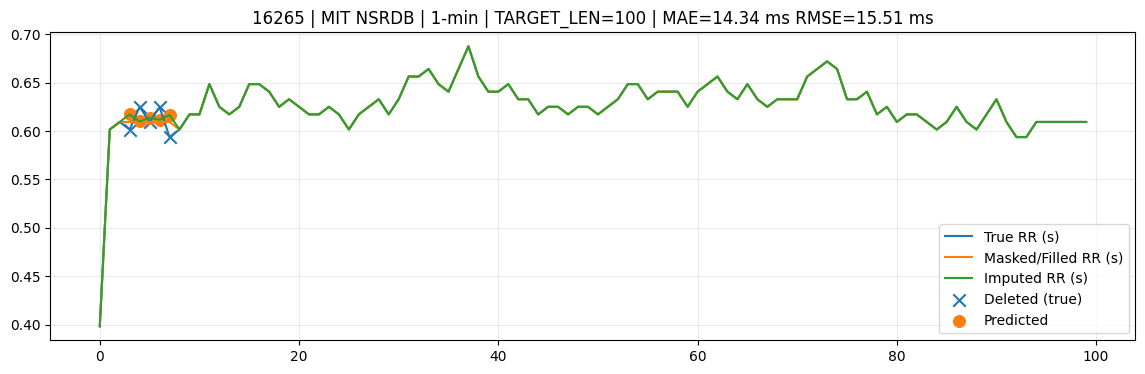

Saved: /kaggle/working/rr_imputer_mit_nsrdb_1min_wgangp_lstm_residual_seconds.pt


In [8]:
# ============================================================
# KAGGLE FULL NOTEBOOK (ALL-IN-ONE) ✅ (MIT NSRDB | 1-MINUTE)
# RR Interval Imputation (SECONDS) with:
#   - LSTM Generator (residual over baseline fill)
#   - WGAN-GP Critic (CNN)
#   - Missing-only MAE + dRR physiology loss
#   - Patient-wise split
#   - Debug prints + plot
# ============================================================

import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import wfdb

# -------------------------
# CONFIG  (SECONDS)
# -------------------------
DATASET_ROOT = "/kaggle/input/mith-normal-sinus-dataset/mit-bih-normal-sinus-rhythm-database-1.0.0"

SEG_S        = 60.0       # ✅ 1 minute
TARGET_LEN   = 100        # ✅ fixed beats per 1-min segment
MIN_LEN_KEEP = 60         # ✅ must be <= TARGET_LEN

K_MISSING    = 5
FILL_MODE    = "ffill"    # "mean" or "ffill"

BATCH_SIZE   = 32         # will be auto-capped to dataset size
EPOCHS       = 30
WARMUP_EPOCHS= 5
N_CRITIC     = 1

LR_G         = 1e-4
LR_D         = 1e-4

LAMBDA_MISS  = 500.0
LAMBDA_DRR   = 2.0
LAMBDA_SMOOTH= 0.0

GP_LAMBDA    = 10.0
SEED         = 42

# -------------------------
# Reproducibility
# -------------------------
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 1) LOAD RR FROM WFDB ANNOTATIONS (*.atr)
# ============================================================
def list_records(dataset_root: str):
    rec_path = os.path.join(dataset_root, "RECORDS")
    if os.path.isfile(rec_path):
        with open(rec_path, "r") as f:
            return [ln.strip() for ln in f if ln.strip()]
    return sorted([fn.replace(".hea","") for fn in os.listdir(dataset_root) if fn.endswith(".hea")])

def load_rr_records_from_wfdb(dataset_root: str, ann_ext="atr", verbose=True):
    rr_dict, fs_dict = {}, {}
    recs = list_records(dataset_root)
    if verbose:
        print(f"Found {len(recs)} records.")

    for rec in recs:
        try:
            rec_path = os.path.join(dataset_root, rec)
            header = wfdb.rdheader(rec_path)
            fs = float(header.fs) if header.fs is not None else None
            if fs is None:
                raise RuntimeError("Header fs is None")

            ann = wfdb.rdann(rec_path, ann_ext)
            samples = np.asarray(ann.sample, dtype=np.int64)
            if samples.size < 2:
                raise RuntimeError("Not enough annotations")

            rr_s = (np.diff(samples) / fs).astype(np.float32)
            rr_s = rr_s[np.isfinite(rr_s)]
            rr_s = rr_s[(rr_s > 0.2) & (rr_s < 3.0)]

            if rr_s.size < 1000:
                raise RuntimeError(f"Too few RR after cleaning: {rr_s.size}")

            rr_dict[rec] = rr_s
            fs_dict[rec] = fs
        except Exception as e:
            if verbose:
                print(f"Skip {rec}: {e}")

    if verbose:
        print(f"\nLoaded {len(rr_dict)} RR records (from annotations).")
        if len(rr_dict) > 0:
            all_rr = np.concatenate(list(rr_dict.values())).astype(np.float64)
            p1, p50, p99 = np.percentile(all_rr, [1, 50, 99])
            print("\nRR scale check (seconds):")
            print(f"  1% / 50% / 99%: {p1:.4f} / {p50:.4f} / {p99:.4f}")
            hr = 60.0 / all_rr
            print("HR sanity (BPM): min={:.1f} mean={:.1f} max={:.1f}".format(
                np.min(hr), np.mean(hr), np.max(hr)
            ))
    return rr_dict, fs_dict

rr_dict, fs_dict = load_rr_records_from_wfdb(DATASET_ROOT, ann_ext="atr", verbose=True)
assert len(rr_dict) > 0, "❌ rr_dict empty. Check DATASET_ROOT or ann_ext."

# ============================================================
# 2) BUILD TRUE 1-MINUTE SEGMENTS (60s)
# ============================================================
def split_into_time_segments(rr_s: np.ndarray, seg_s=60.0):
    segments, acc, cur = [], 0.0, []
    for v in rr_s:
        v = float(v)
        cur.append(v)
        acc += v
        if acc >= seg_s:
            segments.append(np.asarray(cur, dtype=np.float32))
            acc -= seg_s
            cur = []
    return segments

def make_fixed_length(seg: np.ndarray, target_len=100, min_keep=60):
    L = len(seg)
    if L < min_keep:
        return None, None
    if L >= target_len:
        start = np.random.randint(0, L - target_len + 1)
        x = seg[start:start+target_len].copy()
        valid = np.ones((target_len,), dtype=np.float32)
        return x, valid
    else:
        x = np.empty((target_len,), dtype=np.float32)
        valid = np.zeros((target_len,), dtype=np.float32)
        x[:L] = seg
        valid[:L] = 1.0
        x[L:] = seg[-1]  # pad with last
        return x, valid

fixed_samples = []
segments_by_patient = {}

for pid, rr in rr_dict.items():
    segs = split_into_time_segments(rr, seg_s=SEG_S)
    segments_by_patient[pid] = segs
    for seg in segs:
        x, valid = make_fixed_length(seg, target_len=TARGET_LEN, min_keep=MIN_LEN_KEEP)
        if x is not None:
            fixed_samples.append((pid, x, valid))

print(f"\nBuilt {len(fixed_samples)} fixed-length samples from 1-min segments.")

# ============================================================
# 3) TRAIN/TEST SPLIT (PATIENT-WISE ✅)
# ============================================================
all_pids = sorted(list(rr_dict.keys()))
random.shuffle(all_pids)

n_train = int(0.8 * len(all_pids))
train_pids = set(all_pids[:n_train])
test_pids  = set(all_pids[n_train:])

train_samples = [(pid,x,v) for (pid,x,v) in fixed_samples if pid in train_pids]
test_samples  = [(pid,x,v) for (pid,x,v) in fixed_samples if pid in test_pids]

print(f"\nPatient-wise split:")
print(f"  Train patients: {len(train_pids)} | Train samples: {len(train_samples)}")
print(f"  Test  patients: {len(test_pids)}  | Test samples : {len(test_samples)}")

assert len(train_samples) > 0, "❌ No train samples. Lower MIN_LEN_KEEP or adjust TARGET_LEN."

# ============================================================
# 4) DATASET + MASKING
# ============================================================
class RR1MinDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        pid, x, valid = self.samples[idx]
        return pid, torch.tensor(x, dtype=torch.float32), torch.tensor(valid, dtype=torch.float32)

def make_mask_and_corrupt(x, valid_mask, K=5, fill_mode="ffill"):
    B, T = x.shape
    m = torch.ones((B, T), device=x.device)
    idx_missing_list = []

    for b in range(B):
        valid_idx = torch.where(valid_mask[b] > 0.5)[0]
        if valid_idx.numel() <= K:
            idx = valid_idx
        else:
            # 50% contiguous, 50% scattered
            if torch.rand(1, device=x.device).item() < 0.5:
                min_i = int(valid_idx.min().item())
                max_i = int(valid_idx.max().item())
                start = torch.randint(min_i, max_i - K + 2, (1,), device=x.device).item()
                idx = torch.arange(start, start + K, device=x.device)
            else:
                perm = valid_idx[torch.randperm(valid_idx.numel(), device=x.device)]
                idx = perm[:K]

        m[b, idx] = 0.0
        idx_missing_list.append(idx)

    if fill_mode == "mean":
        obs_sum = (x * m).sum(dim=1, keepdim=True)
        obs_cnt = m.sum(dim=1, keepdim=True).clamp(min=1.0)
        fill = obs_sum / obs_cnt
        x_obs = x * m + fill * (1.0 - m)

    elif fill_mode == "ffill":
        x_obs = x.clone()
        for b in range(B):
            missing = (m[b] == 0)
            valid_idx = torch.where(valid_mask[b] > 0.5)[0]
            if valid_idx.numel() == 0:
                continue
            first = int(valid_idx[0].item())
            prev = x_obs[b, first].item()
            for t in range(T):
                if valid_mask[b, t] < 0.5:
                    continue
                if missing[t]:
                    x_obs[b, t] = prev
                else:
                    prev = x_obs[b, t].item()
    else:
        raise ValueError("fill_mode must be 'mean' or 'ffill'")

    return x_obs, m, idx_missing_list

def drr(x):
    dx = x[:, 1:] - x[:, :-1]
    dx = torch.cat([torch.zeros((x.size(0), 1), device=x.device), dx], dim=1)
    return dx

# ============================================================
# 5) MODELS
# ============================================================
class LSTMGeneratorResidual(nn.Module):
    def __init__(self, hidden=96, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=4, hidden_size=hidden, num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x_base, m, noise):
        dx = drr(x_base)
        inp = torch.stack([x_base, m, dx, noise], dim=-1)
        h, _ = self.lstm(inp)
        delta = self.head(h).squeeze(-1)
        return delta

class CNNWganCritic(nn.Module):
    def __init__(self, channels=64, kernel=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        h = self.net(x)
        h = self.pool(h).squeeze(-1)
        return self.fc(h).squeeze(-1)

def gradient_penalty(critic, real, fake, gp_lambda=10.0):
    B = real.size(0)
    eps = torch.rand(B, 1, device=real.device).expand_as(real)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)
    scores = critic(x_hat)
    grads = torch.autograd.grad(
        outputs=scores, inputs=x_hat,
        grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(B, -1)
    gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean() * gp_lambda
    return gp

# ============================================================
# 6) TRAIN
# ============================================================
def train_wgan(train_samples):
    ds = RR1MinDataset(train_samples)

    # ✅ SAFE BATCH SIZE (no zero batches)
    bs = min(BATCH_SIZE, len(ds))
    dl = DataLoader(ds, batch_size=bs, shuffle=True, drop_last=False)
    print("Train samples:", len(ds), "| Using batch size:", bs, "| Batches:", len(dl))

    G = LSTMGeneratorResidual(hidden=96, num_layers=2, dropout=0.1).to(device)
    D = CNNWganCritic(channels=64, kernel=5).to(device)

    opt_g = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.9))
    opt_d = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.9))

    all_vals = np.concatenate([x for (_, x, _) in train_samples]).astype(np.float64)
    lo, hi = np.percentile(all_vals, [0.5, 99.5]).astype(np.float32)
    lo, hi = float(lo), float(hi)
    print(f"RR clamp range (0.5%..99.5%): [{lo:.4f}, {hi:.4f}] s")

    for ep in range(1, EPOCHS + 1):
        G.train(); D.train()
        d_sum = g_sum = miss_sum = drr_sum = 0.0

        for _, x_s, valid in dl:
            x_s = x_s.to(device)
            valid = valid.to(device)

            mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
            var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
            std = torch.sqrt(var).clamp(min=1e-6)
            x = (x_s - mu) / std

            # ---- Critic ----
            for _ in range(N_CRITIC):
                with torch.no_grad():
                    x_base, m, _ = make_mask_and_corrupt(x, valid, K=K_MISSING, fill_mode=FILL_MODE)
                    noise = torch.rand_like(x) * (1.0 - m)
                    delta = G(x_base, m, noise)
                    x_hat = m * x + (1.0 - m) * (x_base + delta)
                    x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

                real_score = D(x)
                fake_score = D(x_hat)
                gp = gradient_penalty(D, x, x_hat, gp_lambda=GP_LAMBDA)
                d_loss = (fake_score.mean() - real_score.mean()) + gp

                opt_d.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_d.step()

            # ---- Generator ----
            x_base, m, _ = make_mask_and_corrupt(x, valid, K=K_MISSING, fill_mode=FILL_MODE)
            noise = torch.rand_like(x) * (1.0 - m)
            delta = G(x_base, m, noise)
            x_hat = m * x + (1.0 - m) * (x_base + delta)
            x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

            adv = -D(x_hat).mean()
            if ep <= WARMUP_EPOCHS:
                adv = 0.0 * adv

            miss_mask = (1.0 - m) * valid
            denom = miss_mask.sum().clamp(min=1.0)
            miss_mae = (torch.abs(x_hat - x) * miss_mask).sum() / denom

            drr_hat = x_hat[:, 1:] - x_hat[:, :-1]
            drr_true = x[:, 1:] - x[:, :-1]
            valid_pair = valid[:, 1:] * valid[:, :-1]
            m_pair = m[:, 1:] * m[:, :-1]
            miss_drr_mask = (1.0 - m_pair) * valid_pair
            denom_drr = miss_drr_mask.sum().clamp(min=1.0)
            drr_loss = (torch.abs(drr_hat - drr_true) * miss_drr_mask).sum() / denom_drr

            smooth = torch.mean(torch.abs(drr_hat) * valid_pair) if LAMBDA_SMOOTH > 0 else torch.tensor(0.0, device=device)

            g_loss = adv + LAMBDA_MISS * miss_mae + LAMBDA_DRR * drr_loss + LAMBDA_SMOOTH * smooth

            opt_g.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_g.step()

            d_sum += float(d_loss.item())
            g_sum += float(g_loss.item())
            miss_sum += float(miss_mae.item())
            drr_sum += float(drr_loss.item())

        denom_print = max(1, len(dl))
        print(
            f"Epoch {ep:03d} | D={d_sum/denom_print:.4f} | G={g_sum/denom_print:.4f} | "
            f"MissMAE(z)={miss_sum/denom_print:.4f} | dRRloss(z)={drr_sum/denom_print:.4f}"
        )

    return G, D, lo, hi

# ============================================================
# 7) INFERENCE + DEBUG + PLOT
# ============================================================
@torch.no_grad()
def impute_one_sample(G, x_s_np, valid_np, lo, hi, K=5, verbose=True):
    G.eval()
    x_s = torch.tensor(x_s_np, dtype=torch.float32, device=device).unsqueeze(0)
    valid = torch.tensor(valid_np, dtype=torch.float32, device=device).unsqueeze(0)

    mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
    var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
    std = torch.sqrt(var).clamp(min=1e-6)
    x = (x_s - mu) / std

    x_base, m, idx_list = make_mask_and_corrupt(x, valid, K=K, fill_mode=FILL_MODE)
    idx_missing = idx_list[0].detach().cpu().numpy()

    noise = torch.rand_like(x) * (1.0 - m)
    delta = G(x_base, m, noise)
    x_hat = m * x + (1.0 - m) * (x_base + delta)
    x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

    x_hat_s  = x_hat * std + mu
    x_base_s = x_base * std + mu

    x_true    = x_s.squeeze(0).cpu().numpy()
    x_imputed = x_hat_s.squeeze(0).cpu().numpy()
    x_base_out= x_base_s.squeeze(0).cpu().numpy()
    valid_out = valid.squeeze(0).cpu().numpy()

    idx_missing = np.array([i for i in idx_missing if valid_out[i] > 0.5], dtype=int)
    true_missing = x_true[idx_missing]
    pred_missing = x_imputed[idx_missing]
    abs_err = np.abs(pred_missing - true_missing)

    mae = float(np.mean(abs_err)) if abs_err.size > 0 else 0.0
    rmse = float(np.sqrt(np.mean((pred_missing - true_missing) ** 2))) if abs_err.size > 0 else 0.0

    if verbose:
        print("\n================ Missing-value Debug ================")
        print(f"K={K} missing points (valid only)")
        print("Deleted indices        :", idx_missing.tolist())
        print("Deleted TRUE values (s):", np.round(true_missing, 6).tolist())
        print("Predicted values    (s):", np.round(pred_missing, 6).tolist())
        print("Abs error          (s) :", np.round(abs_err, 6).tolist())
        print(f"Missing-only MAE={mae:.6f} s | RMSE={rmse:.6f} s")
        print("=====================================================\n")

    return x_true, x_base_out, x_imputed, valid_out, idx_missing, mae, rmse

def plot_imputation(x_true, x_base, x_imputed, idx_missing, valid_mask, title="RR Imputation (1-min segment)"):
    T = len(x_true)
    plt.figure(figsize=(14,4))
    t = np.arange(T)
    plt.plot(t, x_true, label="True RR (s)")
    plt.plot(t, x_base, label="Masked/Filled RR (s)")
    plt.plot(t, x_imputed, label="Imputed RR (s)")
    if len(idx_missing) > 0:
        plt.scatter(idx_missing, x_true[idx_missing], marker="x", s=80, label="Deleted (true)")
        plt.scatter(idx_missing, x_imputed[idx_missing], marker="o", s=70, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

# ============================================================
# 8) RUN
# ============================================================
G, D, lo, hi = train_wgan(train_samples)

pid, x_s_np, valid_np = test_samples[0]
print("Test patient:", pid)

x_true, x_base, x_imputed, valid_out, idx_missing, mae, rmse = impute_one_sample(
    G, x_s_np, valid_np, lo=lo, hi=hi, K=K_MISSING, verbose=True
)

plot_imputation(
    x_true, x_base, x_imputed, idx_missing, valid_out,
    title=f"{pid} | MIT NSRDB | 1-min | TARGET_LEN={TARGET_LEN} | MAE={mae*1000:.2f} ms RMSE={rmse*1000:.2f} ms"
)

MODEL_PATH = "/kaggle/working/rr_imputer_mit_nsrdb_1min_wgangp_lstm_residual_seconds.pt"
torch.save({
    "G_state": G.state_dict(),
    "D_state": D.state_dict(),
    "lo": lo,
    "hi": hi,
    "seg_s": SEG_S,
    "target_len": TARGET_LEN,
    "min_len_keep": MIN_LEN_KEEP,
    "k_missing": K_MISSING,
    "fill_mode": FILL_MODE,
    "missing_pattern": "50% contiguous block, 50% scattered",
    "normalize": "per-segment z-score",
    "units": "seconds",
    "dataset": "MIT-BIH Normal Sinus Rhythm Database (nsrdb)"
}, MODEL_PATH)
print("Saved:", MODEL_PATH)
